In [36]:
# K-Means

import numpy as np	
import matplotlib.pyplot as plt
import pandas as pd

In [38]:
#importer le dataset

dataset = pd.read_csv('Mall_Customers.csv')
x = dataset.iloc[:, [3,4]].values
print(dataset.shape)
dataset.head(10)

(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [39]:
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

C:\Users\cocog\anaconda3\envs\my_project_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cocog\anaconda3\envs\my_project_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cocog\anaconda3\envs\my_project_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\cocog\anaconda3\envs\my_project_env\Lib\site-packages\sklearn\clust

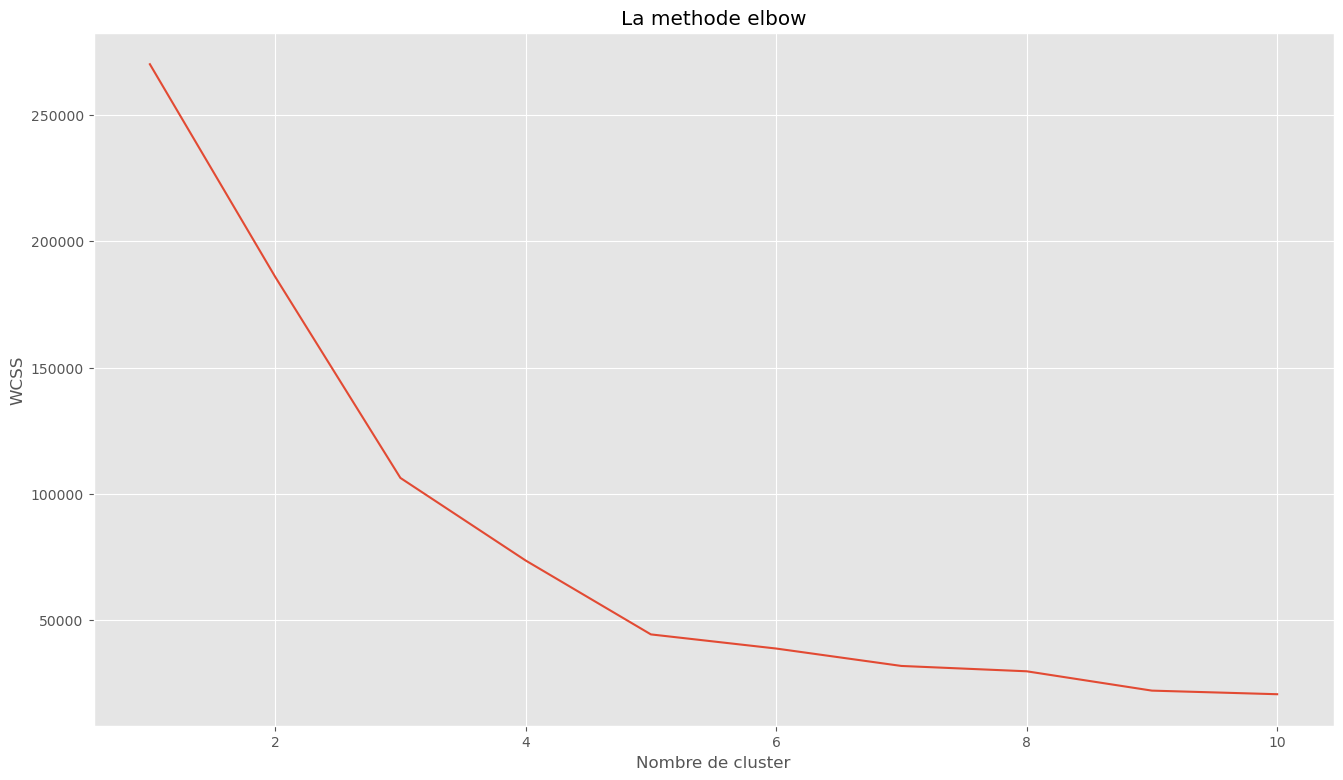

In [40]:
# Utiliser la methode elbow pour trouver le nombre optimal de clusters
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters= i, init= 'k-means++', random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)   
    
plt.plot(range(1,11), wcss)
plt.title('La methode elbow')
plt.xlabel('Nombre de cluster')
plt.ylabel('WCSS')
plt.show()

In [41]:
# Construire les model

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters= 5, init= 'k-means++', random_state=0)
y_kmeans = kmeans.fit_predict(x)

C:\Users\cocog\anaconda3\envs\my_project_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


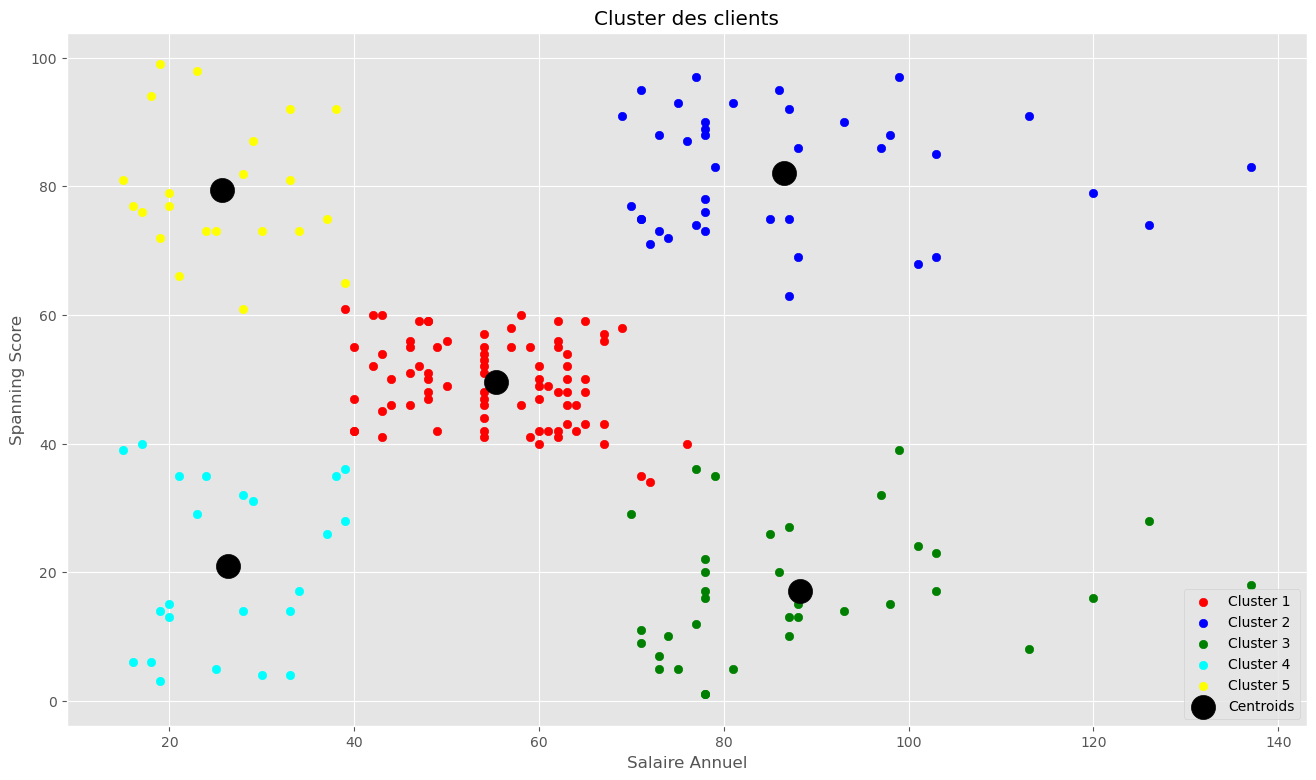

In [42]:
#visualiser les resultats

plt.scatter(x[y_kmeans == 0, 0],x[y_kmeans == 0, 1], c='red', label = 'Cluster 1' )
plt.scatter(x[y_kmeans == 1, 0],x[y_kmeans == 1, 1], c='blue', label = 'Cluster 2' )
plt.scatter(x[y_kmeans == 2, 0],x[y_kmeans == 2, 1], c='green', label = 'Cluster 3' )
plt.scatter(x[y_kmeans == 3, 0],x[y_kmeans == 3, 1], c='cyan', label = 'Cluster 4' )
plt.scatter(x[y_kmeans == 4, 0],x[y_kmeans == 4, 1], c='yellow', label = 'Cluster 5' )
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='black', label='Centroids')

plt.title('Cluster des clients')
plt.xlabel('Salaire Annuel')
plt.ylabel('Spanning Score')
plt.legend()
plt.show()

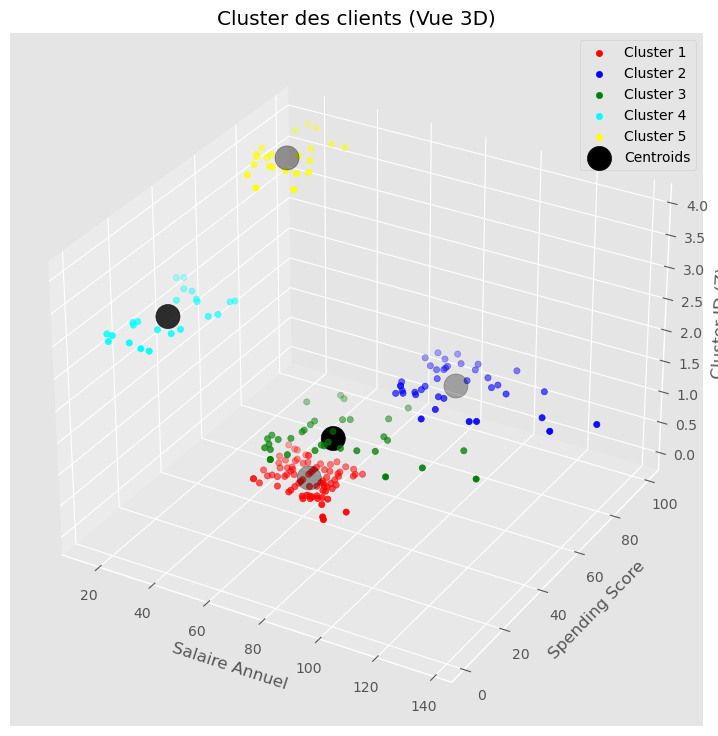

In [44]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Affichage de chaque cluster
ax.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], 0, c='red', label='Cluster 1')
ax.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], 1, c='blue', label='Cluster 2')
ax.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], 2, c='green', label='Cluster 3')
ax.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3, 1], 3, c='cyan', label='Cluster 4')
ax.scatter(x[y_kmeans == 4, 0], x[y_kmeans == 4, 1], 4, c='yellow', label='Cluster 5')

# Affichage des centroïdes
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], [0,1,2,3,4], s=300, c='black', label='Centroids')

ax.set_xlabel('Salaire Annuel')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Cluster ID (Z)')

plt.title('Cluster des clients (Vue 3D)')
ax.legend()
plt.show()
